In [41]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cmocean.cm as cmo
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.feature import NaturalEarthFeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER
import matplotlib.dates as mdates
from matplotlib.ticker import NullFormatter
import datetime as dt
import pandas as pd

%matplotlib inline

In [2]:
from dask.distributed import Client

client = Client()
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 7
Total threads: 14,Total memory: 63.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:38269,Workers: 7
Dashboard: /proxy/8787/status,Total threads: 14
Started: Just now,Total memory: 63.00 GiB
Comm: tcp://127.0.0.1:45909,Total threads: 2
Dashboard: /proxy/41573/status,Memory: 9.00 GiB
Nanny: tcp://127.0.0.1:38151,


### load clim and thresholds

In [3]:
thresh = xr.open_dataset('/scratch/m35/nm5072/TAS_thresholds/om2_025_MLT_thresh.nc')
clim = xr.open_dataset('/scratch/m35/nm5072/TAS_thresholds/om2_025_MLT_clim.nc')
temp = xr.open_dataset('/scratch/m35/nm5072/TAS_thresholds/TAS_MLD_ready.zarr')

/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.04/lib/python3.10/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.04/lib/python3.10/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'h5netcdf' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.04/lib/python3.10/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)


In [45]:
clim

<xarray.Dataset> Size: 52MB
Dimensions:    (yt_ocean: 220, xt_ocean: 160, dayofyear: 366)
Coordinates:
  * xt_ocean   (xt_ocean) float64 1kB -224.9 -224.6 -224.4 ... -185.4 -185.1
  * yt_ocean   (yt_ocean) float64 2kB -59.96 -59.83 -59.71 ... -20.43 -20.19
  * dayofyear  (dayofyear) int64 3kB 1 2 3 4 5 6 7 ... 361 362 363 364 365 366
Data variables:
    temp       (yt_ocean, xt_ocean, dayofyear) float32 52MB 2.567 ... 27.05

In [54]:
clim_box   = clim.temp.sel(xt_ocean=slice(-210, -192), yt_ocean=slice(-44, -38))
thresh_box = thresh.temp.sel(xt_ocean=slice(-210, -192), yt_ocean=slice(-44, -38))
temp_box   = (temp.sel(time=slice('2017-09-01','2017-12-31'))
                  .temp.sel(xt_ocean=slice(-210, -192), yt_ocean=slice(-44, -38)))

clim_mean = clim_box.mean(dim=('xt_ocean', 'yt_ocean'))
thresh_mean = thresh_box.mean(dim=('xt_ocean', 'yt_ocean'))
temp_mean = temp_box.sel(time=slice('2017-09-01','2017-12-31')).mean(dim=('xt_ocean', 'yt_ocean'))

In [55]:
# # Pick the midpoint indices of the domain
# ix = clim.sizes['xt_ocean'] // 2
# iy = clim.sizes['yt_ocean'] // 2

# # (Optional) grab the actual lon/lat of that point for reference
# lon0 = float(clim['xt_ocean'].isel(xt_ocean=ix))
# lat0 = float(clim['yt_ocean'].isel(yt_ocean=iy))
# print(f"Central point selected at lon={lon0:.3f}, lat={lat0:.3f}")

# # Select the central point instead of averaging
# clim_mean   = clim.temp.isel(xt_ocean=ix, yt_ocean=iy)  # dims: dayofyear
# thresh_mean = thresh.temp.isel(xt_ocean=ix, yt_ocean=iy)  # dims: dayofyear
# temp_mean   = (
#     temp.sel(time=slice('2017-09-01', '2017-12-31'))
#         .temp.isel(xt_ocean=ix, yt_ocean=iy)             # dim: time
# )

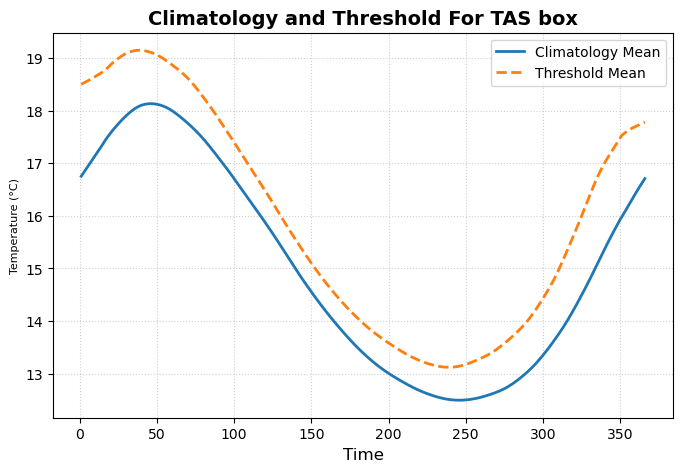

In [56]:
fig, ax = plt.subplots(figsize=(8, 5))

clim_mean.plot(ax=ax, label='Climatology Mean', color='C0', linewidth=2)
thresh_mean.plot(ax=ax, label='Threshold Mean', color='C1', linewidth=2, linestyle='--')

ax.set_title('Climatology and Threshold For TAS box', fontsize=14, fontweight='bold')
ax.set_xlabel('Time', fontsize=12)
ax.set_ylabel('Temperature (°C)', fontsize=8)
ax.legend(fontsize=10, loc='best')
ax.grid(True, linestyle=':', alpha=0.6)

Text(5, 5, '29 Nov 2017')

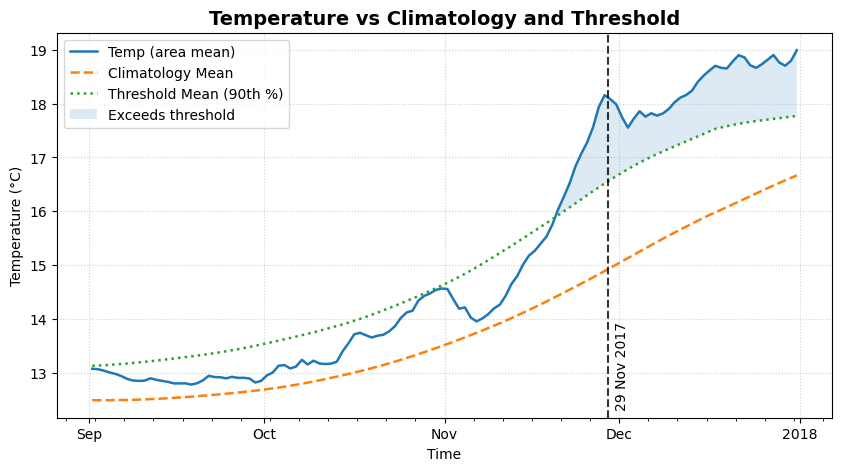

In [58]:
# DOY indexer with a time axis
doy = temp_mean['time'].dt.dayofyear

# These now have dim=('time',) directly — no rename/swap needed
clim_on_time   = clim_mean.sel(dayofyear=doy)
thresh_on_time = thresh_mean.sel(dayofyear=doy)

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
temp_mean.plot(ax=ax, label='Temp (area mean)', linewidth=1.8)
clim_on_time.plot(ax=ax, label='Climatology Mean', linewidth=1.8, linestyle='--')
thresh_on_time.plot(ax=ax, label='Threshold Mean (90th %)', linewidth=1.8, linestyle=':')

# Shaded exceedances
t = temp_mean['time'].values
y_temp = temp_mean.to_numpy()
y_thr  = thresh_on_time.to_numpy()
mask = np.isfinite(y_temp) & np.isfinite(y_thr)

ax.fill_between(t[mask], y_thr[mask], y_temp[mask],
                where=(y_temp[mask] > y_thr[mask]), alpha=0.15, label='Exceeds threshold')

# Formatting
ax.set_title('Temperature vs Climatology and Threshold', fontsize=14, fontweight='bold')
ax.set_xlabel('Time'); ax.set_ylabel('Temperature (°C)')
ax.legend(loc='best'); ax.grid(True, linestyle=':', alpha=0.6)
locator = mdates.AutoDateLocator(minticks=3, maxticks=8)
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))
ax.xaxis.set_minor_locator(mdates.DayLocator(interval=5))
ax.xaxis.set_minor_formatter(NullFormatter())

# Add vertical line for spatial plots
date = dt.datetime(2017, 11, 29)
label_str = date.strftime('%-d %b %Y')  # e.g., "5 Dec 2017"

# Draw the vertical line
ax.axvline(date, color='k', linestyle='--', linewidth=1.5, alpha=0.8)

# Place the annotation near the bottom
ax.annotate(
    label_str,
    xy=(date, ax.get_ylim()[0]),          # bottom of y-axis
    xycoords='data',
    xytext=(5, 5), textcoords='offset points',  # slight offset
    rotation=90, va='bottom', ha='left'
)


### plot spatial maps


In [50]:
def plotmap(data, ax=None, extent=None, lon_name='xt_ocean', lat_name='yt_ocean'):
    """Simple Cartopy map (regional), using given coord names."""
    if ax is None:
        fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(6, 4.5))
    else:
        fig = None

    lon = np.asarray(data[lon_name])
    lat = np.asarray(data[lat_name])
    if extent is None:
        extent = [float(np.nanmin(lon)), float(np.nanmax(lon)),
                  float(np.nanmin(lat)), float(np.nanmax(lat))]

    ax.set_extent(extent, crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND, facecolor='0.9', edgecolor='none')
    ax.coastlines(linewidth=0.6)
    gl = ax.gridlines(draw_labels=True, linestyle=':', linewidth=0.4, alpha=0.6)
    gl.top_labels = False
    gl.right_labels = False
    return fig, ax


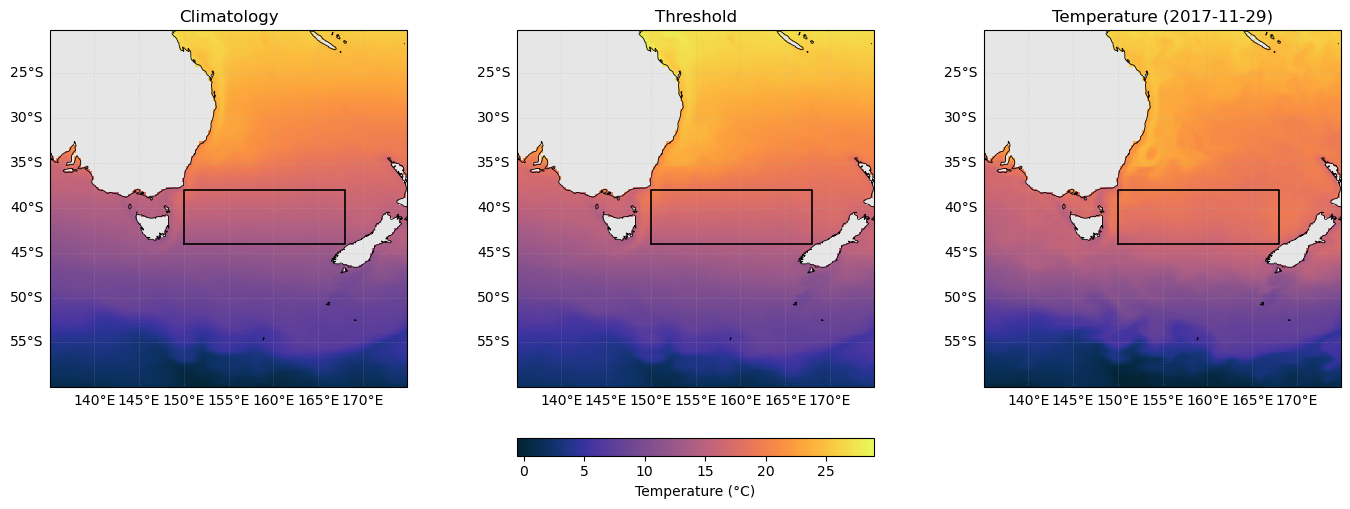

In [61]:
# Convert target lons to ACCESS-OM convention (your grid: -224..-185)
lon_min_ds, lon_max_ds = -210, -192   # 150E, 168E
lat_min, lat_max       = -44, -38

# --- choose date ---
date = '2017-11-29'
doy = pd.to_datetime(date).dayofyear

# Select fields
clim_on_date   = clim.temp.sel(dayofyear=doy)
thresh_on_date = thresh.temp.sel(dayofyear=doy)
temp_on_date   = temp.temp.sel(time=date, method='nearest')

# Common color scale
vmin = float(np.nanmin([clim_on_date.min().item(),
                        thresh_on_date.min().item(),
                        temp_on_date.min().item()]))
vmax = float(np.nanmax([clim_on_date.max().item(),
                        thresh_on_date.max().item(),
                        temp_on_date.max().item()]))

# Figure with three maps
proj = ccrs.PlateCarree()
fig, axes = plt.subplots(1, 3, figsize=(14, 5),
                         subplot_kw={'projection': proj},
                         constrained_layout=True)

panels = [
    (clim_on_date,   'Climatology'),
    (thresh_on_date, 'Threshold'),
    (temp_on_date,   f"Temperature ({pd.to_datetime(temp_on_date['time'].values).date()})"),
]

for ax, (da, title) in zip(axes, panels):
    plotmap(da, ax=ax, lon_name='xt_ocean', lat_name='yt_ocean')
    im = da.plot.pcolormesh(
        ax=ax, transform=proj,
        cmap=cmo.thermal, vmin=vmin, vmax=vmax,
        add_colorbar=False
    )
    ax.set_title(title, fontsize=12)

    # Add black box
    box_lons = [lon_min_ds, lon_max_ds, lon_max_ds, lon_min_ds, lon_min_ds]
    box_lats = [lat_min,    lat_min,    lat_max,    lat_max,    lat_min]
    ax.plot(box_lons, box_lats, color='black', linewidth=1.2, transform=proj)

# Shared colorbar
cbar = fig.colorbar(im, ax=axes.ravel().tolist(),
                    orientation='horizontal', fraction=0.05, pad=0.08)
cbar.set_label('Temperature (°C)')



### make combined plot

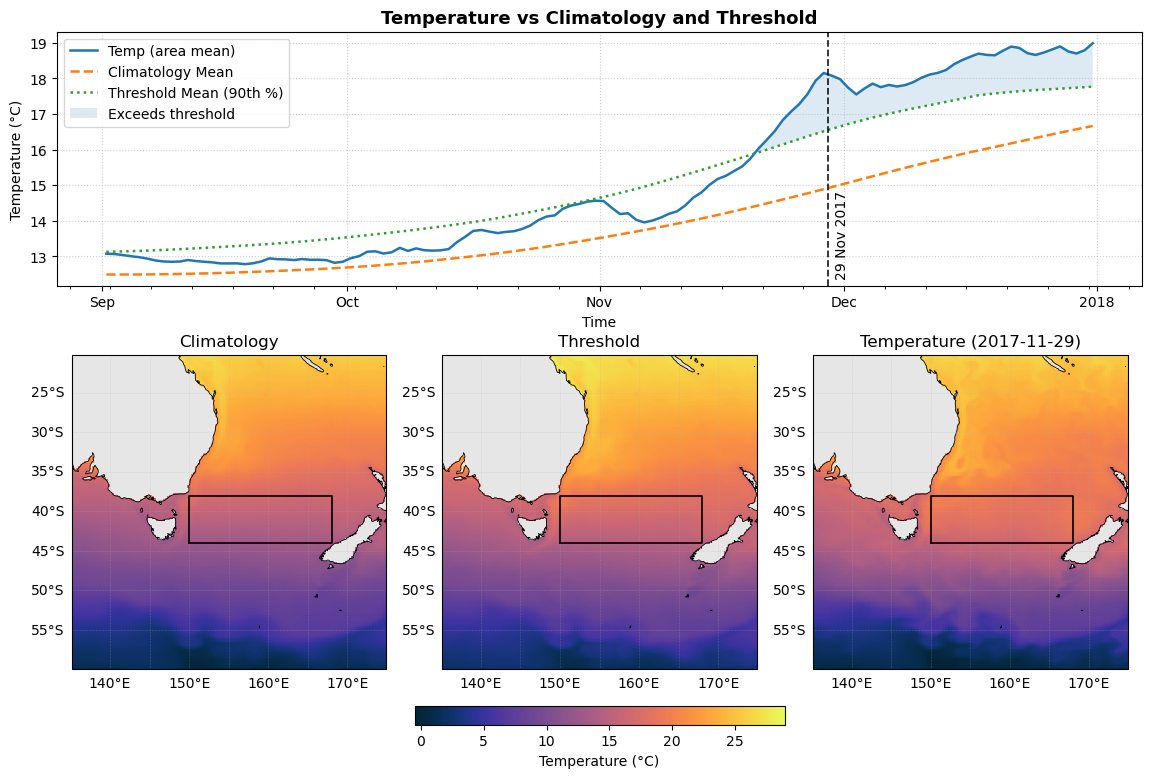

In [64]:
# -------- Subset box (degrees east / south) --------
lon_min_e, lon_max_e = 150.0, 168.0    # 150–168°E
lat_min,   lat_max   = -44.0, -38.0    # 44–38°S

# Map requested longitudes into dataset's convention (handles ACCESS-OM style)
def map_lon_to_ds(lon_e, lon_coord):
    lonmin = float(lon_coord.min()); lonmax = float(lon_coord.max())
    if 0.0 <= lonmin and lonmax <= 360.0:
        return lon_e % 360.0                         # dataset 0..360
    if -180.0 <= lonmin and lonmax <= 180.0:
        return ((lon_e + 180.0) % 360.0) - 180.0     # dataset -180..180
    if lonmax <= 100.0 and lonmin < -180.0:
        return lon_e if lon_e <= lonmax else lon_e - 360.0  # ACCESS-style
    return lon_e

lon_left  = map_lon_to_ds(lon_min_e, clim['xt_ocean'])
lon_right = map_lon_to_ds(lon_max_e, clim['xt_ocean'])
lon_left, lon_right = sorted([lon_left, lon_right])
lat_bot,  lat_top   = sorted([lat_min,  lat_max])

# -------- Date for the vertical line + maps --------
date = dt.datetime(2017, 11, 29)
doy  = pd.to_datetime(date).dayofyear

# -------- Fields for the maps (no wrapping; regional grid) --------
clim_on_date   = clim.temp.sel(dayofyear=doy)               # (yt_ocean, xt_ocean)
thresh_on_date = thresh.temp.sel(dayofyear=doy)             # (yt_ocean, xt_ocean)
temp_on_date   = temp.temp.sel(time=date, method='nearest') # (yt_ocean, xt_ocean)

# Common colour scale across panels
vmin = float(np.nanmin([clim_on_date.min().item(),
                        thresh_on_date.min().item(),
                        temp_on_date.min().item()]))
vmax = float(np.nanmax([clim_on_date.max().item(),
                        thresh_on_date.max().item(),
                        temp_on_date.max().item()]))

# -------- Align climatology/threshold series to time for the top plot --------
doy_series     = temp_mean['time'].dt.dayofyear
clim_on_time   = clim_mean.sel(dayofyear=doy_series)
thresh_on_time = thresh_mean.sel(dayofyear=doy_series)

# ================= FIGURE LAYOUT =================
proj = ccrs.PlateCarree()
fig = plt.figure(figsize=(14, 9))
gs  = fig.add_gridspec(nrows=2, ncols=3, height_ratios=[1.1, 1.6], hspace=0.22, wspace=0.08)

# Top: time series across all columns
ax_ts = fig.add_subplot(gs[0, :])

# Bottom: three maps
ax_c  = fig.add_subplot(gs[1, 0], projection=proj)
ax_th = fig.add_subplot(gs[1, 1], projection=proj)
ax_tm = fig.add_subplot(gs[1, 2], projection=proj)
axes_maps = [ax_c, ax_th, ax_tm]

# ---- Top time series ----
temp_mean.plot(ax=ax_ts, label='Temp (area mean)', linewidth=1.8)
clim_on_time.plot(ax=ax_ts, label='Climatology Mean', linewidth=1.8, linestyle='--')
thresh_on_time.plot(ax=ax_ts, label='Threshold Mean (90th %)', linewidth=1.8, linestyle=':')

# Shaded exceedances
t = temp_mean['time'].values
y_temp = temp_mean.to_numpy()
y_thr  = thresh_on_time.to_numpy()
mask   = np.isfinite(y_temp) & np.isfinite(y_thr)
ax_ts.fill_between(t[mask], y_thr[mask], y_temp[mask],
                   where=(y_temp[mask] > y_thr[mask]),
                   alpha=0.15, label='Exceeds threshold')

# Vertical line + auto label at bottom
ax_ts.axvline(date, color='k', linestyle='--', linewidth=1.3, alpha=0.85)
ax_ts.annotate(date.strftime('%-d %b %Y'),
               xy=(date, ax_ts.get_ylim()[0]), xycoords='data',
               xytext=(5, 5), textcoords='offset points',
               rotation=90, va='bottom', ha='left')

# Axis formatting (concise major labels; 5-day minor ticks without text)
ax_ts.set_title('Temperature vs Climatology and Threshold', fontsize=13, fontweight='bold')
ax_ts.set_xlabel('Time'); ax_ts.set_ylabel('Temperature (°C)')
ax_ts.legend(loc='best'); ax_ts.grid(True, linestyle=':', alpha=0.6)
locator = mdates.AutoDateLocator(minticks=3, maxticks=8)
ax_ts.xaxis.set_major_locator(locator)
ax_ts.xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))
ax_ts.xaxis.set_minor_locator(mdates.DayLocator(interval=5))
ax_ts.xaxis.set_minor_formatter(NullFormatter())

# ---- Bottom maps (use your existing plotmap) ----
panels = [
    (clim_on_date,   ax_c,  'Climatology'),
    (thresh_on_date, ax_th, 'Threshold'),
    (temp_on_date,   ax_tm, f"Temperature ({pd.to_datetime(temp_on_date['time'].values).date()})"),
]

im = None
for da, ax, title in panels:
    # Your plotmap already exists; if it accepts coord-name args, pass them:
    try:
        plotmap(da, ax=ax, lon_name='xt_ocean', lat_name='yt_ocean')
    except TypeError:
        # Fallback if your plotmap only accepts (data, ax)
        plotmap(da, ax=ax)

    im = da.plot.pcolormesh(ax=ax, transform=proj, cmap=cmo.thermal,
                            vmin=vmin, vmax=vmax, add_colorbar=False)
    ax.set_title(title, fontsize=12)

    # Black subset box
    box_lons = [lon_left, lon_right, lon_right, lon_left, lon_left]
    box_lats = [lat_bot,  lat_bot,   lat_top,   lat_top,  lat_bot]
    ax.plot(box_lons, box_lats, color='black', linewidth=1.2, transform=proj)

# Shared colorbar for the maps
cbar = fig.colorbar(im, ax=axes_maps, orientation='horizontal', fraction=0.05, pad=0.1)
cbar.set_label('Temperature (°C)')

### load budget terms

In [ ]:
budget_stavg_daily = xr.open_dataset('/g/data/e14/rmh561/mlt_budget_temporary/mlt_budget_stavg_daily_online_2023.nc')


In [ ]:
budget_stavg_daily